In [8]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

In [4]:
model=YOLO('yolov8n-seg.pt')

In [6]:
model.predict(source='../data/solvay_conference.jpg')
 


image 1/1 c:\Users\dell\Desktop\SALLY\computervission\practice_yolo\..\data\solvay_conference.jpg: 352x640 26 persons, 2 ties, 103.4ms
Speed: 2.3ms preprocess, 103.4ms inference, 16.5ms postprocess per image at shape (1, 3, 352, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 


image 1/1 c:\Users\dell\Desktop\SALLY\computervission\practice_yolo\..\data\solvay_conference.jpg: 352x640 26 persons, 2 ties, 167.9ms
Speed: 3.2ms preprocess, 167.9ms inference, 16.0ms postprocess per image at shape (1, 3, 352, 640)
Results saved to C:\Users\dell\Desktop\SALLY\computervission\runs\segment\predict


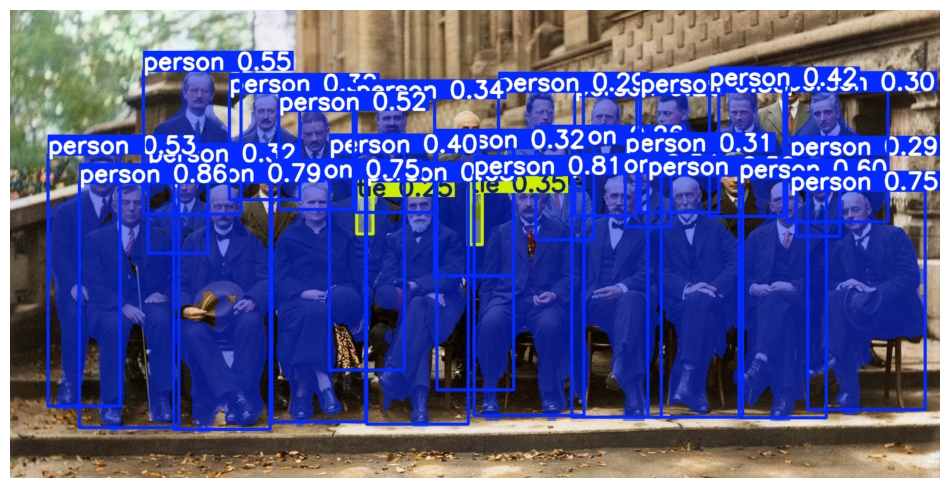

In [18]:
results = model.predict(source='../data/solvay_conference.jpg', save=True)[0]

# Convert BGR (OpenCV) to RGB
img = cv2.cvtColor(results.plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(img)
labels = results.names
plt.axis('off')
plt.show()
 

In [23]:
model2=YOLO('yolov8n-cls.pt')


image 1/1 c:\Users\dell\Desktop\SALLY\computervission\practice_yolo\..\data\solvay_conference.jpg: 224x224 military_uniform 0.55, abaya 0.13, academic_gown 0.04, cornet 0.04, pickelhaube 0.03, 32.5ms
Speed: 15.5ms preprocess, 32.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
Results saved to C:\Users\dell\Desktop\SALLY\computervission\runs\classify\predict2


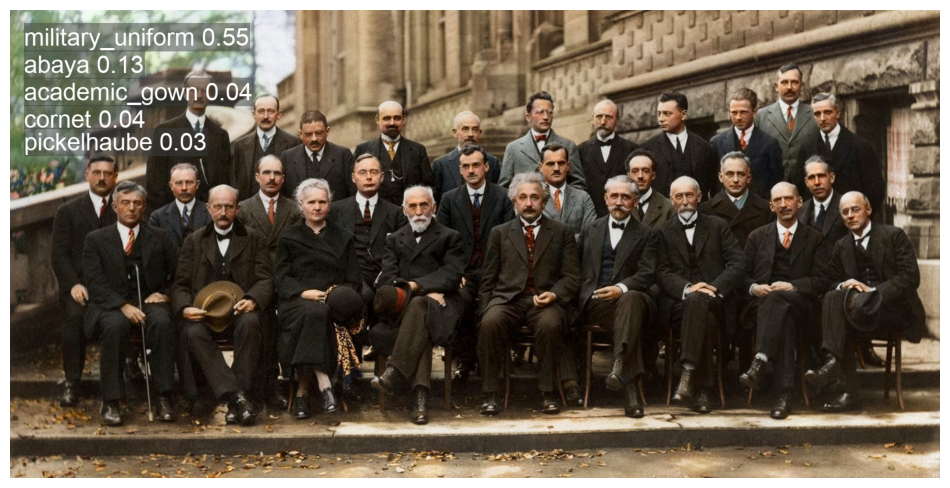

In [24]:
results = model2.predict(source='../data/solvay_conference.jpg', save=True)[0]

# Convert BGR (OpenCV) to RGB
img = cv2.cvtColor(results.plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(img)
labels = results.names
plt.axis('off')
plt.show()


image 1/1 c:\Users\dell\Desktop\SALLY\computervission\practice_yolo\..\data\giraffes.jpg: 224x224 cheetah 0.89, impala 0.03, Arabian_camel 0.02, gazelle 0.02, hartebeest 0.01, 28.1ms
Speed: 13.4ms preprocess, 28.1ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Results saved to C:\Users\dell\Desktop\SALLY\computervission\runs\classify\predict


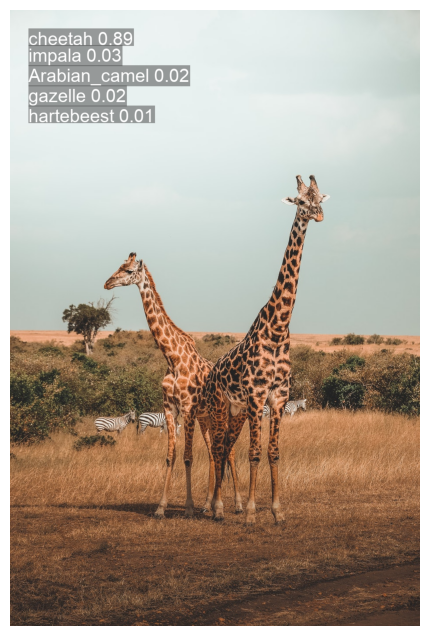

In [21]:

results = model.predict(source='../data/giraffes.jpg', save=True)[0]

# Convert BGR (OpenCV) to RGB
img = cv2.cvtColor(results.plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(img)
labels = results.names
plt.axis('off')
plt.show()


WARNING imgsz=[680] must be multiple of max stride 32, updating to [704]
image 1/1 c:\Users\dell\Desktop\SALLY\computervission\practice_yolo\..\data\solvay_conference.jpg: 384x704 28 persons, 19 ties, 1 baseball bat, 1 tennis racket, 2 chairs, 204.4ms
Speed: 4.3ms preprocess, 204.4ms inference, 2.8ms postprocess per image at shape (1, 3, 384, 704)
Results saved to C:\Users\dell\Desktop\SALLY\computervission\runs\detect\predict25


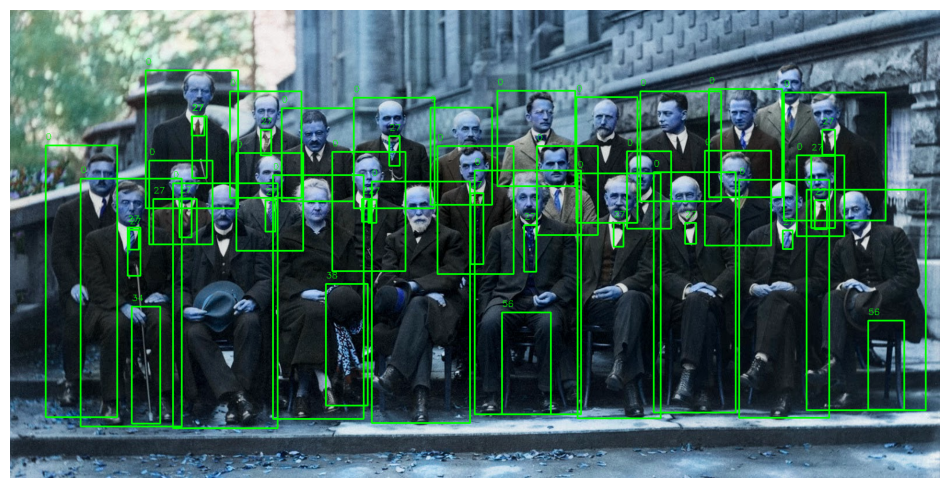

In [ ]:
model = YOLO("yolov8n.pt")  # detection model
#By default, YOLO only keeps boxes above 0.25 confidence. You can lower it to catch more detections
#Larger images give better detection, especially for small objects
#YOLO applies NMS to remove overlapping boxes. You can adjust iou threshold:
# Run detection
results = model.predict(source="../data/solvay_conference.jpg", imgsz= 680  ,
                        # iou=0.3, default 0.5, lower = more overlapping boxes kept
                         conf=0.09, save=True)[0]

img = results.orig_img.copy()

if results.boxes is not None:
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        cls_id = int(box.cls[0].cpu().numpy())
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, f"{cls_id}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
else:
    print("No boxes detected.") 

plt.figure(figsize=(12,8))
plt.imshow(img)
labels = results.names
plt.axis('off')
plt.show()

### customize the display
###

In [35]:
#train modal``
#model3=YOLO()
#train=model3.train(data='data.yaml',epochs=50)